In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [24]:
np.random.seed(42)
n = 500

df = pd.DataFrame({
    "Molecular_Stability": np.random.randint(1,11,n),
    "Binding_Affinity": np.random.randint(1,11,n),
    "Solubility": np.random.randint(1,11,n),
    "Toxicity": np.random.randint(1,11,n),
    "Cell_Response": np.random.randint(1,11,n),
    "Dose_Efficiency": np.random.randint(1,11,n)
})

df.head()

,Molecular_Stability,Binding_Affinity,Solubility,Toxicity,Cell_Response,Dose_Efficiency
0,7,9,1,6,10,5
1,4,1,8,4,6,4
2,8,1,4,4,7,1
3,5,4,4,4,9,5
4,7,9,5,2,1,10


In [11]:
score = (
    0.25*df["Binding_Affinity"] +
    0.20*df["Cell_Response"] +
    0.20*df["Molecular_Stability"] +
    0.15*df["Solubility"] +
    0.10*df["Dose_Efficiency"] +
    0.10*(11-df["Toxicity"])
)

conditions = [
    score >= 8,
    (score >= 6) & (score < 8),
    score < 6
]

choices = ["High", "Medium", "Low"]

df["Response"] = np.select(conditions, choices, default="Low")

df.head()

,Molecular_Stability,Binding_Affinity,Solubility,Toxicity,Cell_Response,Dose_Efficiency,Response
0,7,9,1,6,10,5,Medium
1,4,1,8,4,6,4,Low
2,8,1,4,4,7,1,Low
3,5,4,4,4,9,5,Low
4,7,9,5,2,1,10,Medium


In [12]:
df["Response"].value_counts()

Response
Low       325
Medium    165
High       10
Name: count, dtype: int64

In [13]:
X = df.drop("Response", axis=1)
y = df["Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [15]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.84
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         5
         Low       0.89      0.96      0.92        67
      Medium       0.71      0.71      0.71        28

    accuracy                           0.84       100
   macro avg       0.53      0.56      0.55       100
weighted avg       0.80      0.84      0.82       100



C:\Users\zaman asif\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zaman asif\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zaman asif\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
1,Binding_Affinity,0.286398
4,Cell_Response,0.185356
0,Molecular_Stability,0.179379
2,Solubility,0.156139
5,Dose_Efficiency,0.099325
3,Toxicity,0.093404


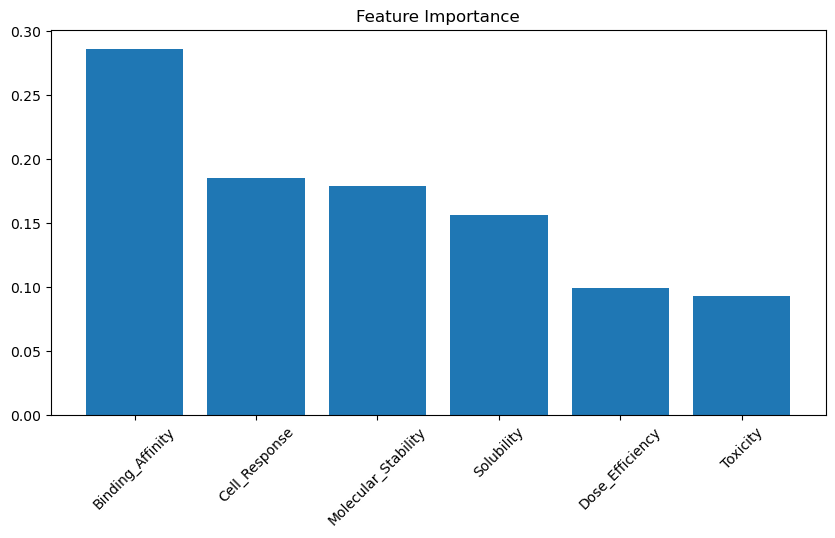

In [17]:
plt.figure(figsize=(10,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [18]:
le = LabelEncoder()
y_encoded = le.fit_transform(df["Response"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\zaman asif\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.4594 - loss: 1.0457 - val_accuracy: 0.5625 - val_loss: 0.9591
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6094 - loss: 0.9445 - val_accuracy: 0.7250 - val_loss: 0.8546
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7656 - loss: 0.8502 - val_accuracy: 0.8000 - val_loss: 0.7459
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8375 - loss: 0.7461 - val_accuracy: 0.9000 - val_loss: 0.6245
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8469 - loss: 0.6347 - val_accuracy: 0.9000 - val_loss: 0.5062
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8656 - loss: 0.5389 - val_accuracy: 0.9250 - val_loss: 0.4121
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8719 - loss: 0.4610 - val_accuracy: 0.9500 - val_loss: 0.3470
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8938 - loss: 0.4079 - val_accuracy: 0.9750 - val_loss

In [21]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("Neural Network Accuracy:", acc)

Neural Network Accuracy: 0.9300000071525574


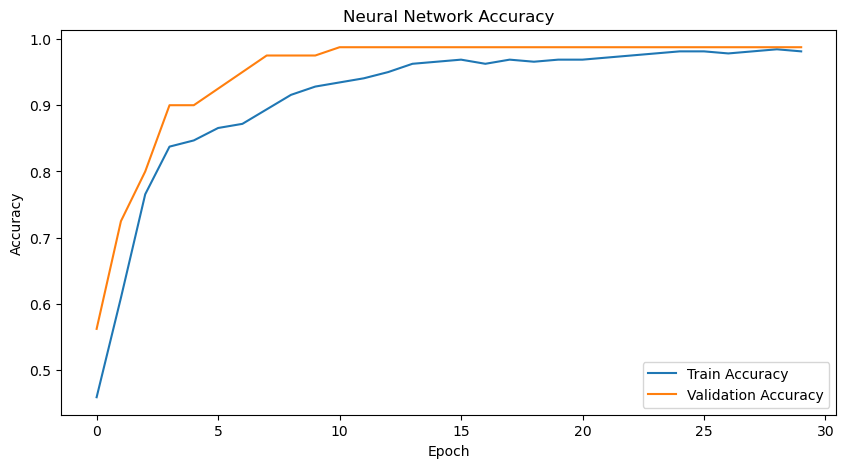

In [22]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [23]:
df.to_csv("drug_response_dataset.csv", index=False)